   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
(8

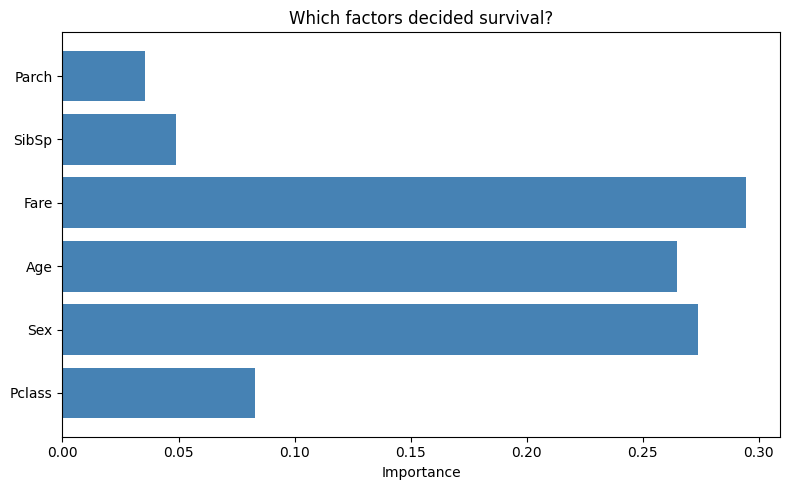

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# ── Load Data ──────────────────────────────────────────────────
df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")

# ── Explore Data ───────────────────────────────────────────────
print(df.head())
print(df.shape)
print(df.describe())
print(df["Survived"].sum())
print(df["Age"].mean())
print(df["Pclass"].value_counts())

# ── Clean Data ─────────────────────────────────────────────────
print(df.isnull().sum())
df["Age"] = df["Age"].fillna(df["Age"].mean())
df = df.drop("Cabin", axis=1)
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
print(df.isnull().sum())

# ── Encode Text to Numbers ─────────────────────────────────────
le = LabelEncoder()
df["Sex"] = le.fit_transform(df["Sex"])
df["Embarked"] = le.fit_transform(df["Embarked"])

# ── Split Data ─────────────────────────────────────────────────
features = ["Pclass", "Sex", "Age", "Fare", "SibSp", "Parch"]
X = df[features]
Y = df["Survived"]
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

# ── Train Model ────────────────────────────────────────────────
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, Y_train)

# ── Evaluate Model ─────────────────────────────────────────────
predictions = model.predict(X_test)
accuracy = accuracy_score(Y_test, predictions)
print("Model Accuracy:", round(accuracy * 100, 2), "%")

# ── Predict Jad's Survival ─────────────────────────────────────
jad = pd.DataFrame(
    [[, 1, 20, 8.05, 0, 0]],
    columns=["Pclass", "Sex", "Age", "Fare", "SibSp", "Parch"]
)
result = model.predict(jad)
if result[0] == 1:
    print("Jad would have SURVIVED! 🎉")
else:
    print("Jad would NOT have survived 😢")

# ── Feature Importance ─────────────────────────────────────────
importance = model.feature_importances_
features_list = ["Pclass", "Sex", "Age", "Fare", "SibSp", "Parch"]
plt.figure(figsize=(8, 5))
plt.barh(features_list, importance, color="steelblue")
plt.title("Which factors decided survival?")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()